In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.ticker as mtick


In [25]:
# Read in the study site data
study_site_data = pd.read_csv('../data/study_site_puc_data.csv')

# Site Dict
site_dict = {
    'Essex Fells, NJ_JCV': 'Essex Fells',
    'PUC-21974-COX': 'Jacksonville'
}
study_site_data['station_name'] = study_site_data['station_name'].map(site_dict)

# Make sure data are in the right format
study_site_data['date'] = pd.to_datetime(study_site_data['timestamp'])
study_site_data['date'] = study_site_data['date'].astype(str)
study_site_data['date'] = [val.split(' ')[0] for val in study_site_data['date']]
study_site_data['date'] = pd.to_datetime(study_site_data['date'])

# Remove today's data because incomplete
today = datetime.now().strftime('%Y-%m-%d')
study_site_data = study_site_data[study_site_data['date'] != today]

# Create only high probability and confidence data
prob_threshold = 0.7
conf_threshold = 0.7
high_prob_conf_df = study_site_data[(study_site_data['confidence'] > conf_threshold) & (study_site_data['probability'] > prob_threshold)].reset_index(drop=True)
high_prob_conf_df = high_prob_conf_df[['id', 'species_common', 'confidence', 'probability', 'station_name', 'timestamp', 'date']]

/var/folders/c5/vpx80swj4yb9ytlnrk8w2qnr0000gn/T/ipykernel_72197/3391546323.py:12: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  study_site_data['date'] = pd.to_datetime(study_site_data['timestamp'])


In [26]:
# Get counts of sounds by date
count_by_date_all = study_site_data.groupby(['date', 'station_name']).agg(
    count = ('id', 'count'), 
    probability = ('probability', 'sum'),   # Historical likelihood of seeing a particular species in this location at this time of year. 
    confidence = ('confidence', 'sum'),     # How confident BirdNET AI is that this is the species identified
    unique_species = ('species_common', 'nunique')
).reset_index()

# Get counts of sounds by date
count_by_date_high_pc = high_prob_conf_df.groupby(['date', 'station_name']).agg(
    count = ('id', 'count'), 
    probability = ('probability', 'sum'),   # Historical likelihood of seeing a particular species in this location at this time of year. 
    confidence = ('confidence', 'sum'),     # How confident BirdNET AI is that this is the species identified
    unique_species = ('species_common', 'nunique')
).reset_index()

In [59]:
def calculate_rolling_sorensen_dissimilarity_by_region_study_site(study_site_df, col_to_process='station_name'):
    daily = study_site_df.copy()
    daily['date'] = pd.to_datetime(daily['date'])
    
    sorensen_results = []
    
    # Process each station separately
    for station in daily[col_to_process].unique():
        station_data = daily[daily[col_to_process] == station].sort_values('date').reset_index(drop=True)
        
        # Create daily presence/absence matrix for this station
        # Use count > 0 to determine presence
        daily_presence = (station_data.groupby(["date", "species_common"])["id"]
                          .count().unstack(fill_value=0) > 0).astype(int)
        
        # Get sorted dates for this station
        dates_sorted = sorted(daily_presence.index)
        
        # Calculate rolling 3-day Sørensen dissimilarity
        for i in range(len(dates_sorted)):
            current_date = dates_sorted[i]
            
            # Define the two 3-day periods to compare
            period_a_dates = []
            period_b_dates = []
            
            # Get dates for period A (7-9 days ago)
            for offset in [9, 8, 7]:
                if i - offset >= 0:
                    period_a_dates.append(dates_sorted[i - offset])
            
            # Get dates for period B (0-2 days ago)
            for offset in [2, 1, 0]:
                if i - offset >= 0:
                    period_b_dates.append(dates_sorted[i - offset])
            
            # Only calculate if we have at least one date in each period
            if len(period_a_dates) > 0 and len(period_b_dates) > 0:
                # Get species presence for each period
                period_a_presence = daily_presence.loc[period_a_dates].any(axis=0)
                period_b_presence = daily_presence.loc[period_b_dates].any(axis=0)
                
                # Calculate Sørensen dissimilarity
                a_sum = period_a_presence.sum()
                b_sum = period_b_presence.sum()
                intersection = (period_a_presence & period_b_presence).sum()
                
                # Sørensen dissimilarity formula: 1 - (2 * intersection) / (a_sum + b_sum)
                denom = (a_sum + b_sum)
                d_s = np.nan if denom == 0 else 1 - (2 * intersection / denom)
                
                sorensen_results.append({
                    'date': current_date,
                    f'{col_to_process}': station,
                    'rolling_sorensen': d_s
                })
            else:
                sorensen_results.append({
                    'date': current_date,
                    f'{col_to_process}': station,
                    'rolling_sorensen': np.nan
                })
    
    # Create result DataFrame
    result_df = pd.DataFrame(sorensen_results)
    
    return result_df


def calculate_hill_q2_by_station(study_site_df, col_to_process='station_name'):
    """
    Calculate Hill Q=2 (Simpson's effective number) per date and station.
    Hill Q=2 = 1 / (sum of p_i^2) where p_i is the proportion of species i
    """
    daily = study_site_df.copy()
    daily['date'] = pd.to_datetime(daily['date'])
    
    hill_results = []
    
    # Process each date-station combination
    for (date, station), group in daily.groupby(['date', f'{col_to_process}']):
        # Count occurrences per species for this date-station
        species_counts = group.groupby('species_common')['id'].count()
        
        # Calculate proportions
        total_count = species_counts.sum()
        if total_count > 0:
            proportions = species_counts / total_count
            
            # Calculate Hill Q=2: 1 / sum(p_i^2)
            sum_squared_proportions = (proportions ** 2).sum()
            hill_q2 = 1 / sum_squared_proportions if sum_squared_proportions > 0 else np.nan
        else:
            hill_q2 = np.nan
        
        hill_results.append({
            'date': date,
            f'{col_to_process}': station,
            'hill_q_2': hill_q2
        })
    
    # Create result DataFrame
    result_df = pd.DataFrame(hill_results)
    
    return result_df

In [ ]:
# Calculate the metrics
rolling_sorensen_all = calculate_rolling_sorensen_dissimilarity_by_region_study_site(study_site_data)
hill_q2_all = calculate_hill_q2_by_station(study_site_data)

rolling_sorensen_high_pc = calculate_rolling_sorensen_dissimilarity_by_region_study_site(high_prob_conf_df)
hill_q2_high_pc = calculate_hill_q2_by_station(high_prob_conf_df)

# Merge with count_by_date
count_by_date_all = count_by_date_all.merge(
    rolling_sorensen_all[['date', 'station_name', 'rolling_sorensen']], 
    on=['date', 'station_name'], 
    how='left'
)
count_by_date_all = count_by_date_all.merge(
    hill_q2_all[['date', 'station_name', 'hill_q_2']], 
    on=['date', 'station_name'], 
    how='left'
)

# Merge with count_by_date
count_by_date_high_pc = count_by_date_high_pc.merge(
    rolling_sorensen_high_pc[['date', 'station_name', 'rolling_sorensen']], 
    on=['date', 'station_name'], 
    how='left'
)
count_by_date_high_pc = count_by_date_high_pc.merge(
    hill_q2_high_pc[['date', 'station_name', 'hill_q_2']], 
    on=['date', 'station_name'], 
    how='left'
)

In [39]:
def plot_puc_data(station_name=None, puc_name=None, prob_threshold=prob_threshold, conf_threshold=conf_threshold):
    plot_all = count_by_date_all.loc[count_by_date_all['station_name'] == station_name]
    plot_high_pc = count_by_date_high_pc.loc[count_by_date_high_pc['station_name'] == station_name]
    # Plot trends - 2x3 subplot
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(28, 12), sharex=True)
    fig.tight_layout(pad=4.0)

    # Define plot configurations: (row, col, column_name, ylabel)
    plot_configs = [
        (0, 0, 'count', 'Number of Sounds'),
        (0, 1, 'probability', 'Probability'),
        (0, 2, 'confidence', 'Confidence'),
        (1, 0, 'unique_species', 'Unique Species'),
        (1, 1, 'rolling_sorensen', 'Rolling Sørensen'),
        (1, 2, 'hill_q_2', 'Hill Q=2'),
    ]

    # Plot each metric
    for row, col, col_name, ylabel in plot_configs:
        ax = axes[row, col]
        
        # Check if column exists in dataframe
        if col_name in count_by_date_all.columns:
            sns.lineplot(
                x='date', 
                y=col_name, 
                data=plot_all, 
                ax=ax, 
                color='black', 
                markers=True,
                marker='o',  
                markersize=10, 
                markeredgewidth=0.5,
                alpha=0.7,
                label='All Data'
            )
            sns.lineplot(
                x='date', 
                y=col_name, 
                data=plot_high_pc, 
                ax=ax, 
                color='red', 
                markers=True,
                marker='o',  
                markersize=10, 
                markeredgewidth=0.5,
                alpha=0.7,
                label=f'High PC Data (p={prob_threshold}, c={conf_threshold})'
            )
            ax.set_ylabel(ylabel, fontsize=30, labelpad=8)
            ax.tick_params(labelsize=18)
            
            # Only show x-axis labels on bottom row
            if row == 1:
                ax.set_xlabel('Date', fontsize=30, labelpad=8)
                # Format dates properly
                ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
                ax.tick_params(axis='x', labelsize=18, rotation=45)
            else:
                ax.set_xlabel('')
                ax.tick_params(axis='x', labelbottom=False)
            
            # Only show legend on first subplot (custom labels for each hue)
            if row == 0 and col == 0:
                ax.legend(fontsize=20, frameon=False)
            else:
                ax.legend().remove()
        else:
            # If column doesn't exist, show a message
            ax.text(0.5, 0.5, f'Column "{col_name}"\nnot found', 
                    ha='center', va='center', fontsize=12, 
                    transform=ax.transAxes)
            ax.set_ylabel(ylabel, fontsize=30, labelpad=8)
            if row == 1:
                ax.set_xlabel('Date', fontsize=30, labelpad=12)
        
        sns.despine(top=True, right=True, ax=ax)

    plt.suptitle(f"{puc_name}", fontsize=40)
    plt.subplots_adjust(wspace=0.2, hspace=0.1)
    plt.show()
    return fig

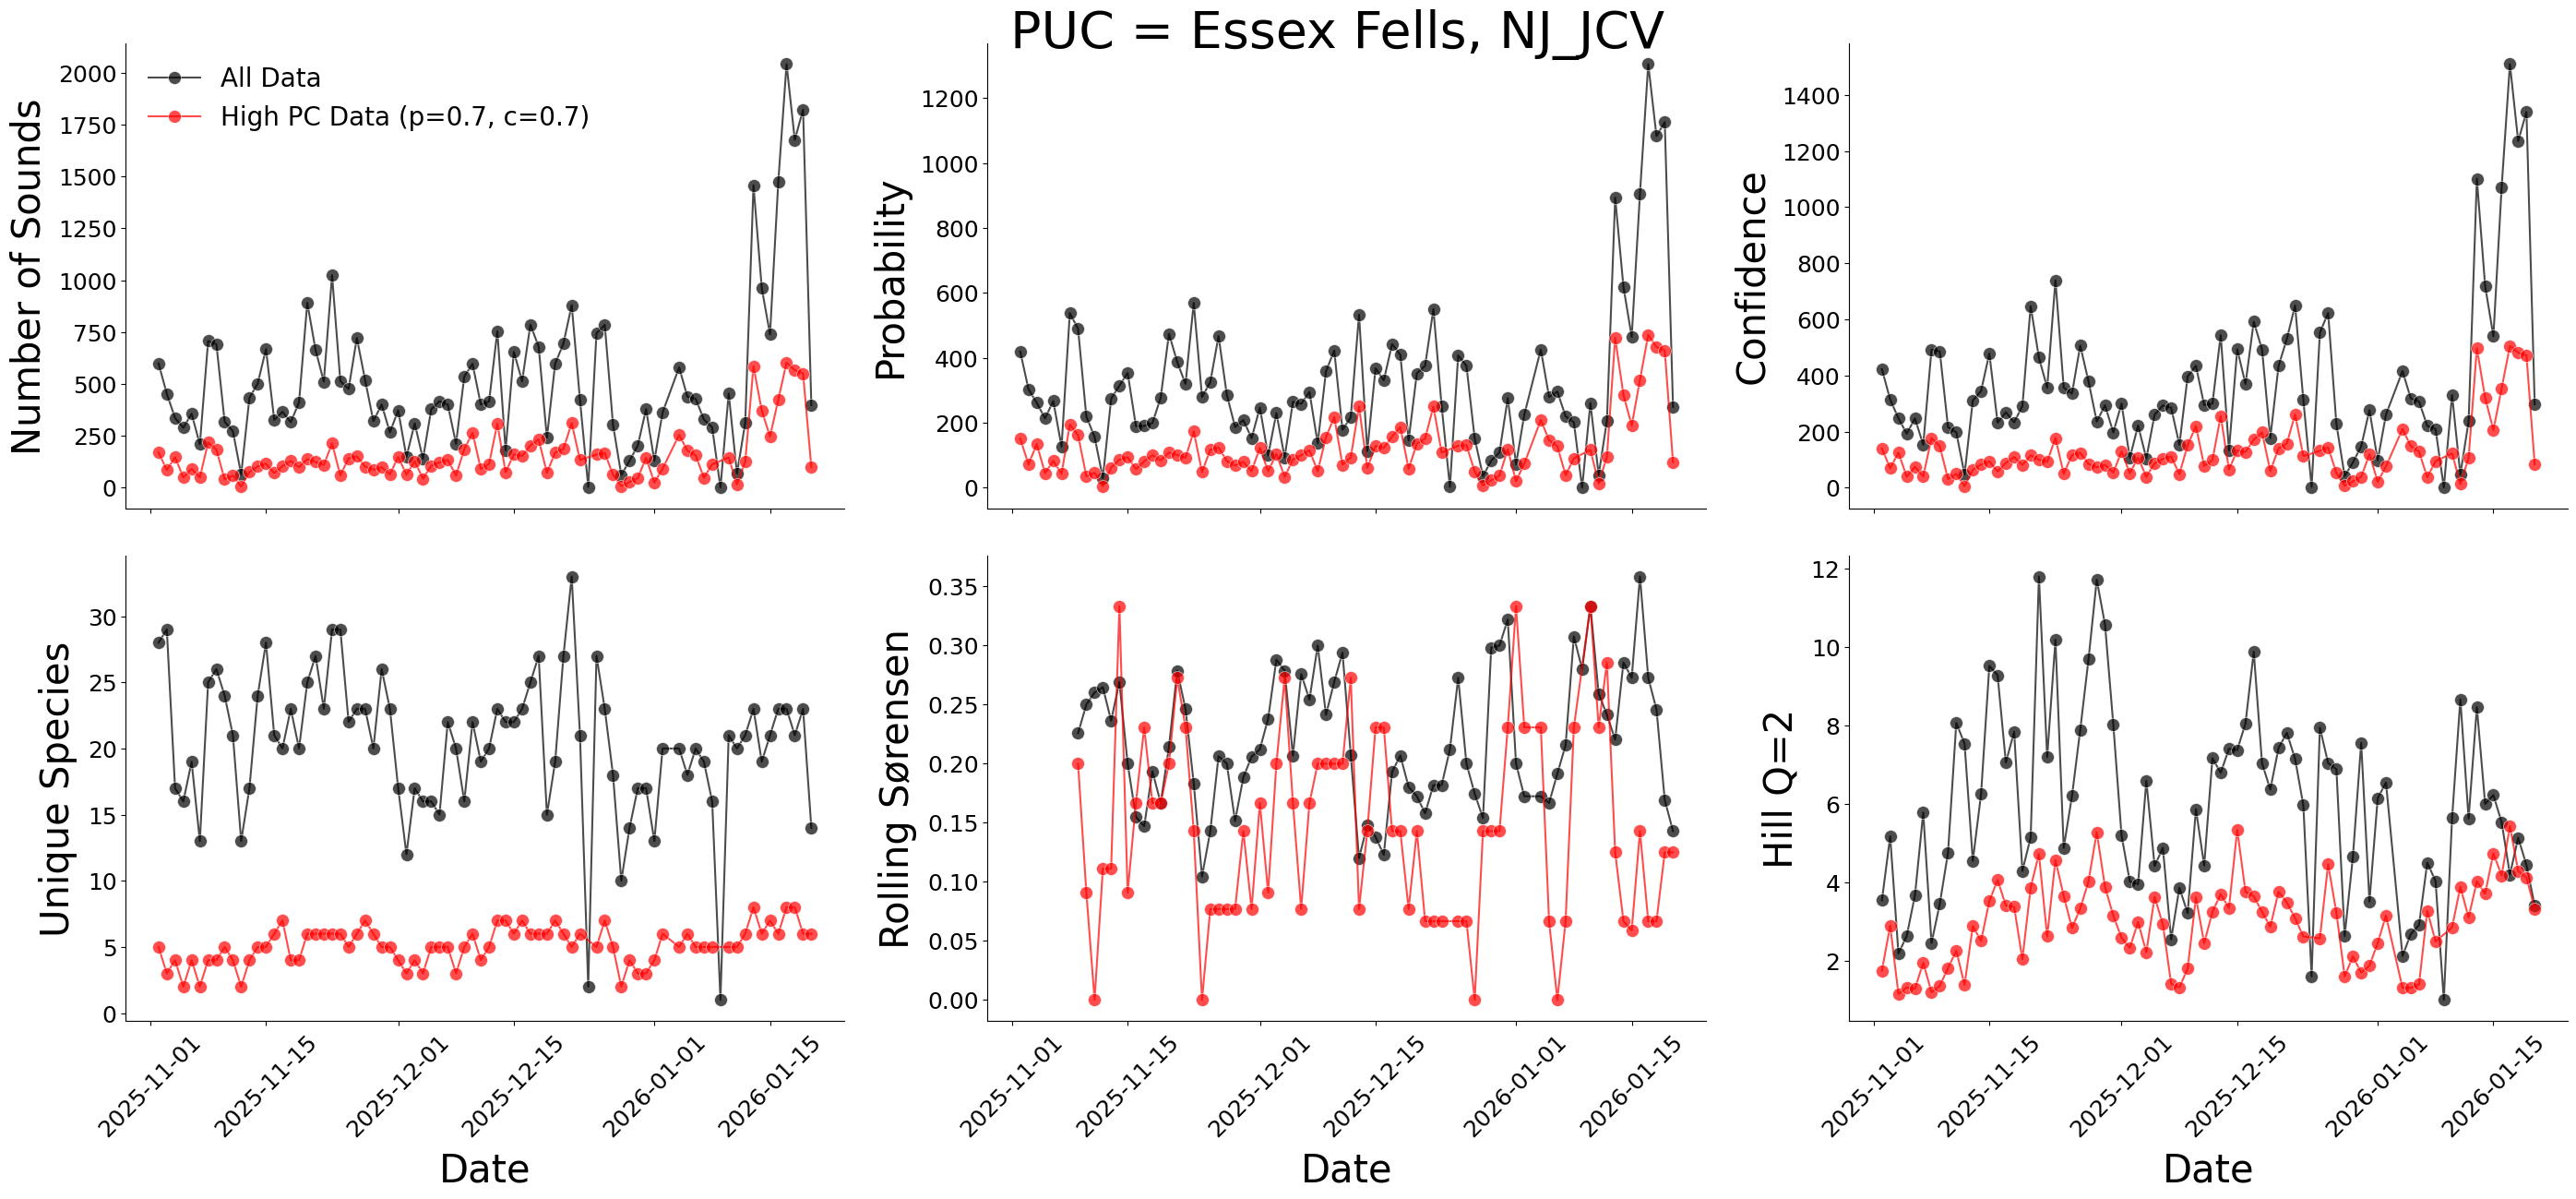

In [40]:
fig = plot_puc_data(station_name='Essex Fells', puc_name='PUC = Essex Fells, NJ_JCV')

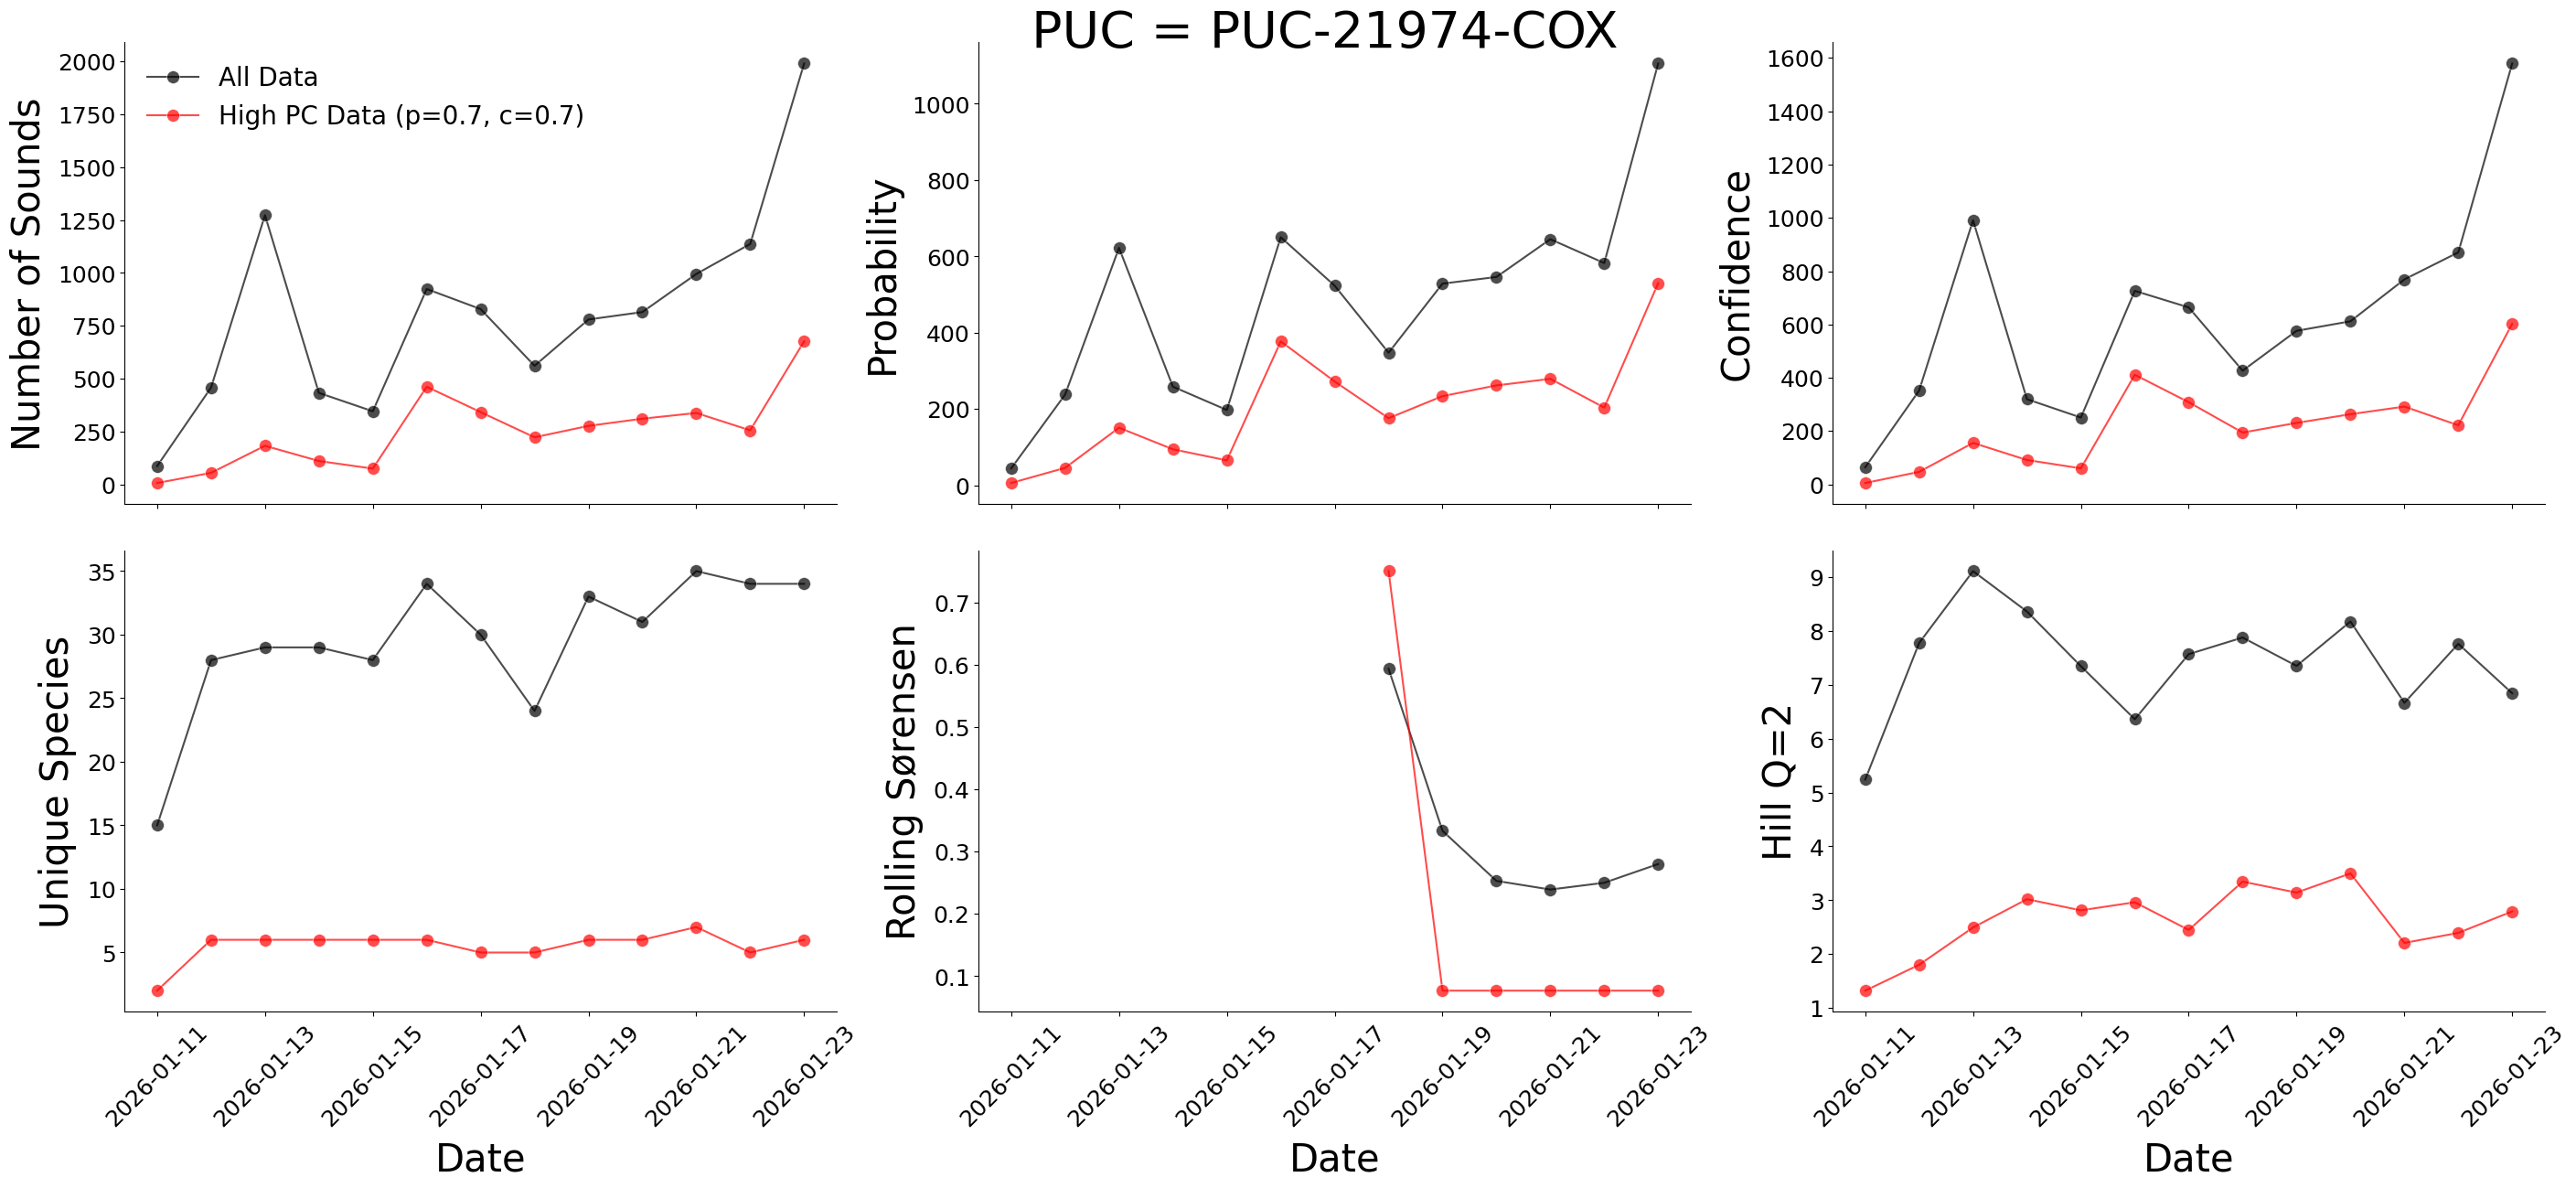

In [41]:
fig = plot_puc_data(station_name='Jacksonville', puc_name='PUC = PUC-21974-COX')

## County PUC data

In [104]:
# Read in all PUC data from surrounding county
county_puc_data = pd.read_parquet('../data/county_level_birdweather.parquet')

# Make sure data are in the right format
county_puc_data['date'] = pd.to_datetime(county_puc_data['timestamp'])
county_puc_data['date'] = county_puc_data['date'].astype(str)
county_puc_data['date'] = [val.split(' ')[0] for val in county_puc_data['date']]
county_puc_data['date'] = pd.to_datetime(county_puc_data['date'])
county_puc_data = county_puc_data[county_puc_data['date'] >= '2025-06-01']

# Remove today's data because incomplete
today = datetime.now().strftime('%Y-%m-%d')
county_puc_data = county_puc_data[county_puc_data['date'] != today]

# Create only high probability and confidence data
county_puc_data_high_pc = county_puc_data[(county_puc_data['confidence'] > conf_threshold) & (county_puc_data['probability'] > prob_threshold)].reset_index(drop=True)

In [105]:
# Get counts of sounds by date
count_by_date_all_county = county_puc_data.groupby(['date', 'county']).agg(
    count = ('id', 'count'), 
    probability = ('probability', 'sum'), 
    confidence = ('confidence', 'sum'),   
    unique_species = ('species_common', 'nunique')
).reset_index()

# Get counts of sounds by date
count_by_date_high_pc_county = county_puc_data_high_pc.groupby(['date', 'county']).agg(
    count = ('id', 'count'), 
    probability = ('probability', 'sum'), 
    confidence = ('confidence', 'sum'),   
    unique_species = ('species_common', 'nunique')
).reset_index()

# Calculate the metrics
rolling_sorensen_all_county = calculate_rolling_sorensen_dissimilarity_by_region_study_site(county_puc_data, col_to_process='county')
hill_q2_all_county = calculate_hill_q2_by_station(county_puc_data, col_to_process='county')

rolling_sorensen_high_pc_county = calculate_rolling_sorensen_dissimilarity_by_region_study_site(county_puc_data_high_pc, col_to_process='county')
hill_q2_high_pc_county = calculate_hill_q2_by_station(county_puc_data_high_pc, col_to_process='county')

# Merge with count_by_date
count_by_date_all_county = count_by_date_all_county.merge(
    rolling_sorensen_all_county[['date', 'county', 'rolling_sorensen']], 
    on=['date', 'county'], 
    how='left'
)
count_by_date_all_county = count_by_date_all_county.merge(
    hill_q2_all_county[['date', 'county', 'hill_q_2']], 
    on=['date', 'county'], 
    how='left'
)

# Merge with count_by_date
count_by_date_high_pc_county = count_by_date_high_pc_county.merge(
    rolling_sorensen_high_pc_county[['date', 'county', 'rolling_sorensen']], 
    on=['date', 'county'], 
    how='left'
)
count_by_date_high_pc_county = count_by_date_high_pc_county.merge(
    hill_q2_high_pc_county[['date', 'county', 'hill_q_2']], 
    on=['date', 'county'], 
    how='left'
)

In [ ]:
# Add station relations for merging
count_by_date_all_county['station_name'] = count_by_date_all_county['county'].map({
    'essex_nj': 'Essex Fells', 
    'duval_fl': 'Jacksonville', 
    'st_johns_fl': 'St. Johns',
})

# Merge study site with county
count_by_date_merge = count_by_date_all.merge(
    count_by_date_all_county,
    on=['date', 'station_name'],
    how='right', 
    suffixes=('_study_site', '_county')
)

,date,county,count,probability,confidence,unique_species,rolling_sorensen,hill_q_2,station_name
21,2025-06-11,st_johns_fl,8552,4270.673643,7092.099663,64,0.165644,9.770408,St. Johns
333,2025-11-12,essex_nj,133,79.515143,98.299672,19,NaN,6.573393,Essex Fells
287,2025-10-22,st_johns_fl,4996,2949.800327,4045.126737,61,0.164557,12.750484,St. Johns
293,2025-10-25,st_johns_fl,3030,1799.138963,2444.919749,48,0.222930,12.446990,St. Johns
369,2025-11-24,essex_nj,579,321.266902,404.049594,33,0.090909,5.612137,Essex Fells


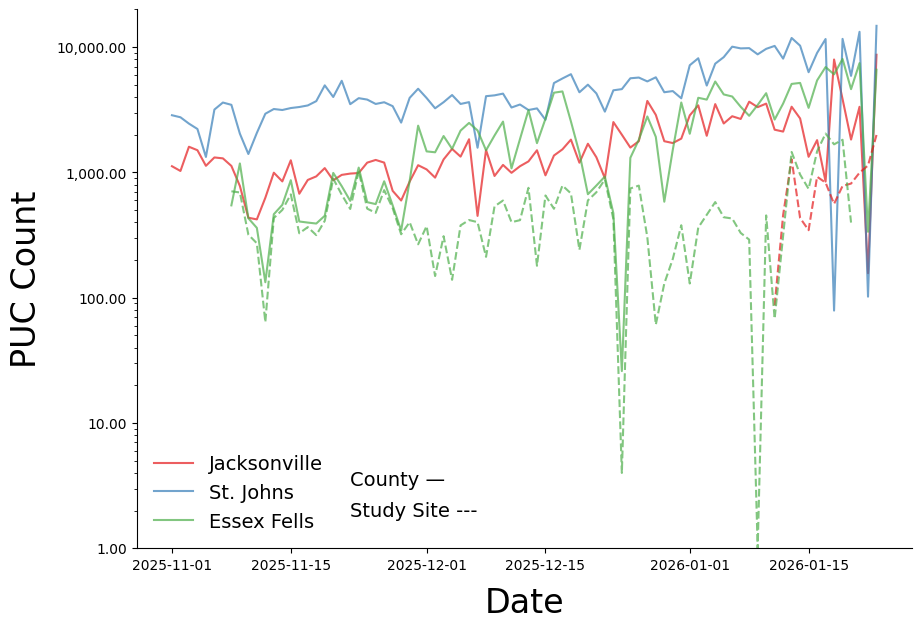

In [165]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.lineplot(
    x='date', y='count_county', 
    data=count_by_date_merge[count_by_date_merge['date'] >= '2025-11-01'], 
    hue='station_name', palette='Set1', alpha=0.7, 
    # markers=True, markersize=6, marker='o', markeredgewidth=0.5,
)
sns.lineplot(
    x='date', y='count_study_site', 
    data=count_by_date_merge[count_by_date_merge['date'] >= '2025-11-01'], 
    hue='station_name', palette='Set1', alpha=0.7, 
    linestyle='--', legend=False, 
    # markers=True, markersize=6, marker='o', markeredgewidth=0.5,
)
plt.text(x=datetime(2025, 11, 22), y=2.0, s='Study Site ---', fontsize=14, ha='left', va='center')
plt.text(x=datetime(2025, 11, 22), y=3.5, s='County —', fontsize=14, ha='left', va='center')

ax.set_xlabel('Date', fontsize=24, labelpad=10)
ax.set_ylabel('PUC Count', fontsize=24, labelpad=10)
plt.yscale('log')
plt.ylim(1, 20_000)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x:,.2f}'))
sns.despine(top=True, right=True, ax=ax)
ax.legend(loc='lower left', fontsize=14, frameon=False)
plt.show()
